# SPA capability set vs. actual visits

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [2]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import h3.api.numpy_int as h3
from tqdm import tqdm
from shapely.geometry import Polygon
import numpy as np
from scipy.stats import hypergeom
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib as mpl
from joblib import Parallel, delayed
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib import rcParams
rcParams['font.family'] = 'Segoe UI Emoji'  # For Windows

In [3]:
file_path = "dbs/data_p/commuter_sp_set_r.parquet"
df_set = pd.read_parquet(file_path)

In [4]:
poi_set = df_set['poi_id'].unique()
print(len(poi_set))

44333


In [5]:
gdf_poi = gpd.read_file('dbs/geo/pois.gpkg')
gdf_poi = gdf_poi[gdf_poi['id'].isin(poi_set)]

In [6]:
gdf_poi['lat'], gdf_poi['lon'] = gdf_poi.geometry.y, gdf_poi.geometry.x

In [7]:
h3_resolution = 8

Calculating H3 IDs: 100%|██████████| 44146/44146 [00:00<00:00, 120035.52it/s]


<Axes: >

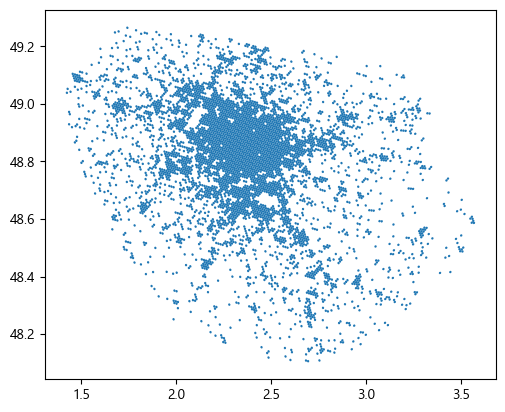

In [8]:
# Concatenate and drop duplicates
unique_coords = gdf_poi[['lon', 'lat']].drop_duplicates()

# Reset index for clarity
unique_coords = unique_coords.reset_index(drop=True)

# Get corresponding h3 id (10) for each coordinate pair
tqdm.pandas(desc="Calculating H3 IDs")
unique_coords['h3_id'] = unique_coords.progress_apply(lambda row: h3.latlng_to_cell(row['lat'], row['lon'], res=h3_resolution), axis=1)
# Extract unique h3_ids
h3_list = unique_coords['h3_id'].unique().tolist()
polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in h3_list]

# Create a GeoDataFrame from unique h3_ids
gdf_h3 = gpd.GeoDataFrame(
    h3_list,
    geometry=polygons,
    crs="EPSG:4326"
)
gdf_h3.columns= ['h3_id', 'geometry']
gdf_h3.plot()

In [9]:
gdf_poi_r = gpd.sjoin(gdf_poi, gdf_h3)
gdf_poi_r = gdf_poi_r[['id', 'h3_id']]

In [ ]:
df_set_r = df_set.merge(gdf_poi_r, left_on='poi_id', right_on='id', how='left')
df_set_r.head()

In [11]:
df_set_r = df_set_r.groupby(['ID', 'mode', 'h3_id'])['time_left'].mean().reset_index()

In [12]:
df = pd.read_parquet(f'dbs/data_p/stays_extraction_all.parquet')

In [13]:
THIRD = {'LEISURE'}
def third_place_visits_h3(group):
    acts = [group['purpose_o'].tolist()[0]] + group['purpose_d'].tolist()
    # Filter third places
    third_places = [x for x in acts if x in THIRD]
    n = len(third_places)

    if n == 0:
        return pd.Series({'h3_visits': []})
    # --- 2) Build lists of coordinate pairs (lat, lon) ---
    # (a) Flat list of all start+end coords across the whole dataframe
    all_coords = (
        list(zip(group["start_lat"], group["start_lon"])) +
        list(zip(group["end_lat"],   group["end_lon"]))
    )
    # Drop NaNs
    all_coords = [(lat, lon) for lat, lon in all_coords
                if pd.notna(lat) and pd.notna(lon)]

    # --- 3) Corresponding H3 r=10 for those coords (same order as all_coords) ---
    all_h3_r10 = [h3.latlng_to_cell(lat, lon, res=h3_resolution) for lat, lon in all_coords]
    all_h3_r10 = [h for h in all_h3_r10 if pd.notna(h)]

    return pd.Series({'h3_visits': list(set(all_h3_r10))})

df_v = df.groupby('ID').apply(third_place_visits_h3).reset_index()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_22800\1738379779.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_v = df.groupby('ID').apply(third_place_visits_h3).reset_index()


## 1. Individual sampling

In [14]:
id_list = df_v.ID.values
feasible_id = []
for i in tqdm(id_list):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    if len(set_s) > 0:
        set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)
        if len(set_v) > 0:
            feasible_id.append(i)
        break

  0%|          | 0/3318 [00:00<?, ?it/s]


In [15]:
set_s.sort_values(by='time_left', ascending=False, inplace=True)
set_s['rank'] = np.arange(1, len(set_s) + 1)

In [16]:
# Define the worker function
def check_feasibility(i):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :]
    if len(set_s) > 0:
        set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values
        if len(set_v) > 0 and len(set_v[0]) > 0:
            return i
    return None

# List of IDs
id_list = df_v.ID.values

# Run in parallel
feasible_id = Parallel(n_jobs=-1)(
    delayed(check_feasibility)(i) for i in tqdm(id_list)
)

# Filter out None results
feasible_id = [i for i in feasible_id if i is not None]

100%|██████████| 3318/3318 [04:00<00:00, 13.80it/s]


In [17]:
def mean_rank_test(visited_ids, df_ranked, B=1000, random_seed=42):
    np.random.seed(random_seed)

    feasible_ids = df_ranked['h3_id'].tolist()
    rank_dict = dict(zip(df_ranked['h3_id'], df_ranked['rank']))
    N_i = len(feasible_ids)

    # Filter only visited places within feasible set
    visited_in_spa = [h for h in visited_ids if h in rank_dict]
    k_i = len(visited_in_spa)

    if k_i == 0:
        return {
            'T_mean_act': np.nan,
            'mu_null': np.nan,
            'sigma_null': np.nan,
            'd_i': np.nan,
            'p_empirical': np.nan,
            'note': 'No visited h3_id in SPA'
        }

    T_act = np.mean([rank_dict[h] for h in visited_in_spa])

    null_T = []
    for _ in range(B):
        rand_draw = np.random.choice(feasible_ids, size=k_i, replace=False)
        null_T.append(np.mean([rank_dict[h] for h in rand_draw]))
    null_T = np.array(null_T)

    p_val = (1 + np.sum(null_T <= T_act)) / (B + 1)
    mu_null = np.mean(null_T)
    sigma_null = np.std(null_T, ddof=1)
    d_i = (T_act - mu_null) / sigma_null if sigma_null > 0 else np.nan

    return {
        'T_mean_act': T_act,
        'mu_null': mu_null,
        'sigma_null': sigma_null,
        'd_i': d_i,
        'p_empirical': p_val,
        'k_i': k_i,
        'excluded_visits': len(visited_ids) - k_i
    }

In [18]:
res1 = mean_rank_test(set_v, set_s)
print("Mean Rank Test:", res1)

Mean Rank Test: {'T_mean_act': nan, 'mu_null': nan, 'sigma_null': nan, 'd_i': nan, 'p_empirical': nan, 'note': 'No visited h3_id in SPA'}


### 1.1 Visualize an example individual

In [19]:
len(feasible_id), feasible_id[0]

(856, '10_2980')

In [20]:
# Get work home locations
df_c = pd.read_csv('dbs/data_p/commuter_trips.csv')
# Step 1: Find rows where HOME is either origin or destination
home_rows = df_c[(df_c['purpose_o'] == 'HOME') | (df_c['purpose_d'] == 'HOME')].copy()
work_rows = df_c[(df_c['purpose_o'] == 'WORK') | (df_c['purpose_d'] == 'WORK')].copy()

# Step 2: Create home_lat, home_lon columns based on where HOME is found
home_rows['home_lat'] = home_rows.apply(
    lambda row: row['start_lat'] if row['purpose_o'] == 'HOME' else row['end_lat'], axis=1)
home_rows['home_lon'] = home_rows.apply(
    lambda row: row['start_lon'] if row['purpose_o'] == 'HOME' else row['end_lon'], axis=1)

# Step 3: Do the same for work
work_rows['work_lat'] = work_rows.apply(
    lambda row: row['start_lat'] if row['purpose_o'] == 'WORK' else row['end_lat'], axis=1)
work_rows['work_lon'] = work_rows.apply(
    lambda row: row['start_lon'] if row['purpose_o'] == 'WORK' else row['end_lon'], axis=1)

# Step 4: For each ID, get the *first* occurrence of HOME and WORK
home_locs = home_rows.groupby('ID')[['home_lat', 'home_lon']].first().reset_index()
work_locs = work_rows.groupby('ID')[['work_lat', 'work_lon']].first().reset_index()

# Step 5: Merge HOME and WORK info
home_work_df = pd.merge(home_locs, work_locs, on='ID', how='outer')
location_dict = {}

for _, row in home_work_df.iterrows():
    id_ = row['ID']
    home = (row['home_lat'], row['home_lon']) if pd.notnull(row['home_lat']) and pd.notnull(row['home_lon']) else None
    work = (row['work_lat'], row['work_lon']) if pd.notnull(row['work_lat']) and pd.notnull(row['work_lon']) else None

    location_dict[id_] = {
        "Home": home,
        "Work": work
    }

In [22]:
i = feasible_id[56]
for i in feasible_id:
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)

    # Compute the intersection
    intersection = set(set_s['h3_id']).intersection(set(set_v))
    ratio = len(intersection)/len(set_v) 
    if (ratio > 0.8) & (ratio < 1.0):
        print(len(intersection), len(set_v), len(set_s))
        break

11 13 79


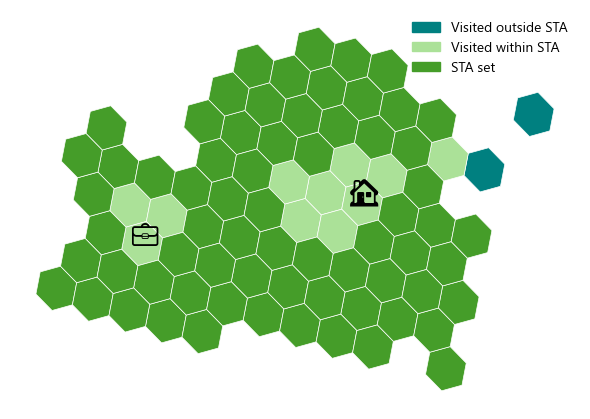

In [30]:
def visualize_h3_ids(h3_list_v, h3_list_s):
    intersection = set(h3_list_s).intersection(set(h3_list_v))
    polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in intersection]

    # Create a GeoDataFrame from unique h3_ids
    gdf_h3_1 = gpd.GeoDataFrame(
        intersection,
        geometry=polygons,
        crs="EPSG:4326"
    )
    gdf_h3_1.columns= ['h3_id', 'geometry']
    gdf_h3_1.loc[:, 'label'] = 'Visited within STA'

    tp_outside = [x for x in h3_list_v if x not in intersection]
    polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in tp_outside]

    # Create a GeoDataFrame from unique h3_ids
    gdf_h3_2 = gpd.GeoDataFrame(
        tp_outside,
        geometry=polygons,
        crs="EPSG:4326"
    )
    gdf_h3_2.columns= ['h3_id', 'geometry']
    gdf_h3_2.loc[:, 'label'] = 'Visited outside STA'

    # Create a GeoDataFrame for the second set of H3 IDs
    tp = [x for x in h3_list_s if x not in h3_list_v]
    polygons_s = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in tp]
    gdf_h3_s = gpd.GeoDataFrame(
        tp,
        geometry=polygons_s,
        crs="EPSG:4326"
    )
    gdf_h3_s.columns= ['h3_id', 'geometry']
    gdf_h3_s.loc[:, 'label'] = 'STA set'
    return pd.concat([gdf_h3_1, gdf_h3_2, gdf_h3_s], ignore_index=True)

gdf_plot = visualize_h3_ids(set_v, set_s['h3_id'].tolist())
# Define color mapping manually
color_dict = {
    'Visited outside STA': 'teal',
    'Visited within STA': '#ABE198',
    'STA set': '#459D29'
}

# Plot base map
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot polygons by category with manual color
for label, color in color_dict.items():
    gdf_plot[gdf_plot['label'] == label].plot(
        ax=ax,
        color=color,
        edgecolor='white',
        linewidth=0.5
    )

# Plot home and work points
# Plot emoji markers using text
ax.text(
    location_dict[i]['Home'][1], location_dict[i]['Home'][0],
    '🏠', fontsize=18, ha='center', va='center'
)
ax.text(
    location_dict[i]['Work'][1], location_dict[i]['Work'][0],
    '💼', fontsize=18, ha='center', va='center'
)

# Manually define legend patches for polygons
legend_patches = [
    mpatches.Patch(color=color, label=label) for label, color in color_dict.items()
]

# Add point handles for Home and Work
legend_handles = legend_patches # + [home, work]

# Draw the legend with no box
ax.legend(handles=legend_handles, frameon=False)

# Final cleanup
ax.axis('off')
plt.tight_layout()
fig.savefig("figures/sta_example.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Scale up to all individuals

In [21]:
test_results = []
for i in tqdm(feasible_id):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)
    set_s.sort_values(by='time_left', ascending=False, inplace=True)
    set_s.loc[:, 'rank'] = np.arange(1, len(set_s) + 1)
    res1 = mean_rank_test(set_v, set_s)
    res1['ID'] = i
    test_results.append(res1)
df_m = pd.DataFrame(test_results)

100%|██████████| 856/856 [02:11<00:00,  6.51it/s]


In [22]:
df_m['k_i'] = df_m['k_i'].fillna(0)
df_m['excluded_visits'] = df_m['excluded_visits'].fillna(99999)

In [23]:
len(df_m[df_m['k_i'] == 0]) / len(df_m) * 100

0.11682242990654204

In [24]:
df_m.loc[:, 'excluded_share'] = df_m.loc[:, 'excluded_visits'] / (df_m.loc[:, 'k_i'] + df_m.loc[:, 'excluded_visits'])
df_m.loc[:, 'excluded_share'] = df_m.apply(lambda row: row['excluded_share'] if row['k_i'] > 0 else 1, axis=1)

In [ ]:
df_p = pd.read_csv("dbs/data_p/commuter_model_features_r.csv")
df_m_r = df_m.merge(df_p[['ID', 'Gender', 'poverty_rate',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'codgeo', 'pt_sub', 'active_mode']], on='ID', how='left')
df_m_r.head()

In [26]:
1-np.average(df_m_r['excluded_share'], weights=df_m_r['weight_ind'])

np.float64(0.7831582677932276)

## 3. Visualize the results

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_22800\2104362426.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_m_r.groupby('bin').size()
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_22800\2104362426.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_counts = df_m_r[df_m_r['main_mode_r'] == 'Car'].groupby('bin').size()


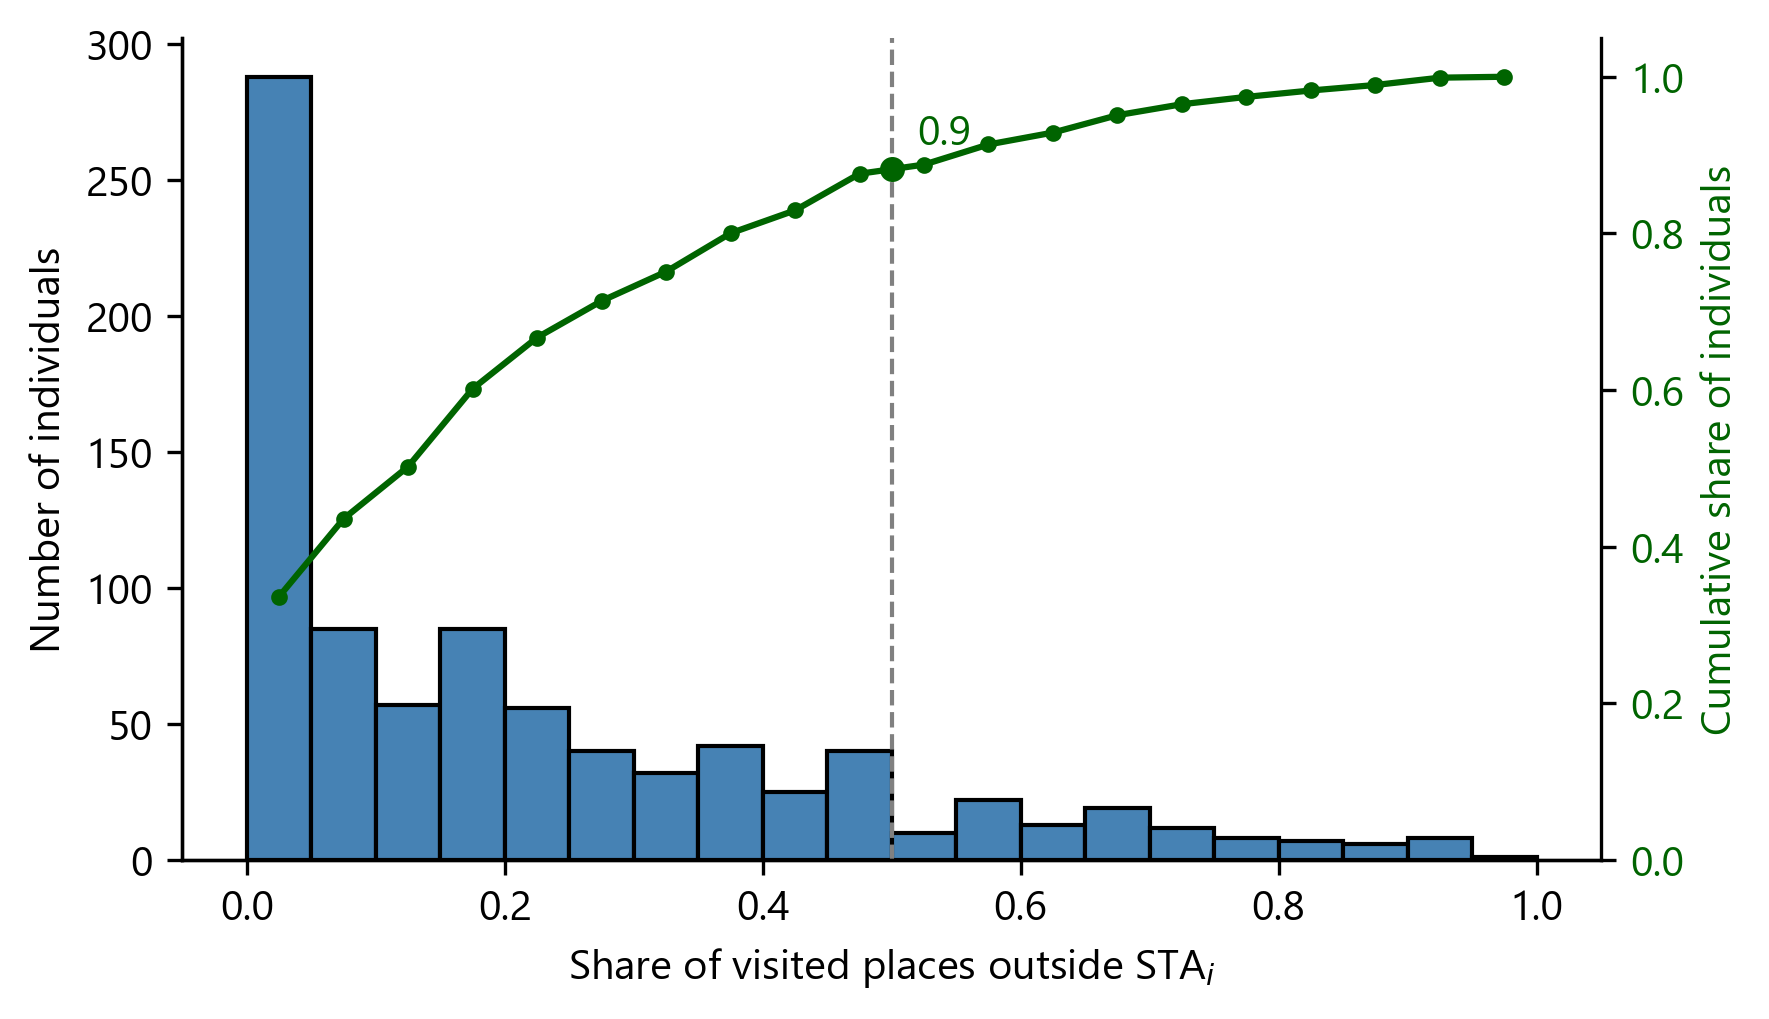

In [32]:
# Step 1: Bin the data
bins = np.linspace(0, 1, 21)  # 20 equal-width bins
df_m_r['bin'] = pd.cut(df_m_r['excluded_share'], bins=bins, include_lowest=True)

# Step 2: Count total vs car users
bin_counts = df_m_r.groupby('bin').size()
car_counts = df_m_r[df_m_r['main_mode_r'] == 'Car'].groupby('bin').size()
car_share = (car_counts / bin_counts).fillna(0)

# Step 3: Cumulative distribution
cum_share = bin_counts.cumsum() / bin_counts.sum()

# Bar positions
heights = bin_counts.values
lefts = bins[:-1]
width = bins[1] - bins[0]
midpoints = (bins[:-1] + bins[1:]) / 2

# Color mapping
colors = cm.Blues(car_share.values)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 3.5), dpi=300)

# Bars
for i in range(len(heights)):
    ax.bar(lefts[i], heights[i], width=width, align='edge',
           color='steelblue', edgecolor='black', alpha=1)  # colors[i]

# Primary axis labels
ax.set_xlabel("Share of visited places outside STA$_i$")
ax.set_ylabel("Number of individuals")

# Remove top spine
ax.spines['top'].set_visible(False)

# -----------------------------
# Secondary y-axis
# -----------------------------
ax2 = ax.twinx()
ax2.plot(midpoints, cum_share.values, color="darkgreen",
         marker="o", markersize=3, linewidth=1.5)

ax2.set_ylabel("Cumulative share of individuals", color="darkgreen")
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.spines['top'].set_visible(False)
ax2.set_ylim(0, 1.05)

# -----------------------------
# Vertical line at x = 0.5
# -----------------------------
x_mark = 0.5

# Interpolate cumulative share at x = 0.5
cum_at_x = np.interp(x_mark, midpoints, cum_share.values)

# Add vertical line
ax.axvline(x_mark, color='gray', linestyle='--', linewidth=1)

# Add intersection point
ax2.plot(x_mark, cum_at_x, 'o', color='darkgreen', markersize=5)

# Add label
ax2.text(
    x_mark + 0.02, cum_at_x + 0.02,
    f"{cum_at_x:.1f}",
    color="darkgreen", fontsize=10, va='bottom'
)

# -----------------------------
# Horizontal TOP colorbar
# -----------------------------
sm = cm.ScalarMappable(
    cmap='Blues',
    norm=plt.Normalize(vmin=min(car_share), vmax=max(car_share))
)
sm.set_array([])

# After creating `ax` and `sm` but BEFORE plt.tight_layout():

# Get the position of the main axes
bbox = ax.get_position()

# Create a new axis for the colorbar above the main plot
# cax = fig.add_axes([
#     bbox.x0 + 0.65,          # same left as main ax
#     bbox.y1 - 0.6,   # a bit above the main ax
#     0.02,       # same width
#     bbox.height*0.5              # height of the colorbar
# ])

# cbar = fig.colorbar(
#     sm,
#     cax=cax,
#     orientation='vertical'
# )
# cbar.set_label("Share of car users")
# cbar.outline.set_visible(False)   # remove frame
# cbar.ax.tick_params(length=0)     # remove tick marks if you like

# Final layout & save
sns.despine(ax=ax, top=True, right=False)
sns.despine(ax=ax2, top=True, left=False)

plt.tight_layout()
fig.savefig("figures/selectivity_excluded_share.png",
            dpi=300, bbox_inches='tight')
plt.show()

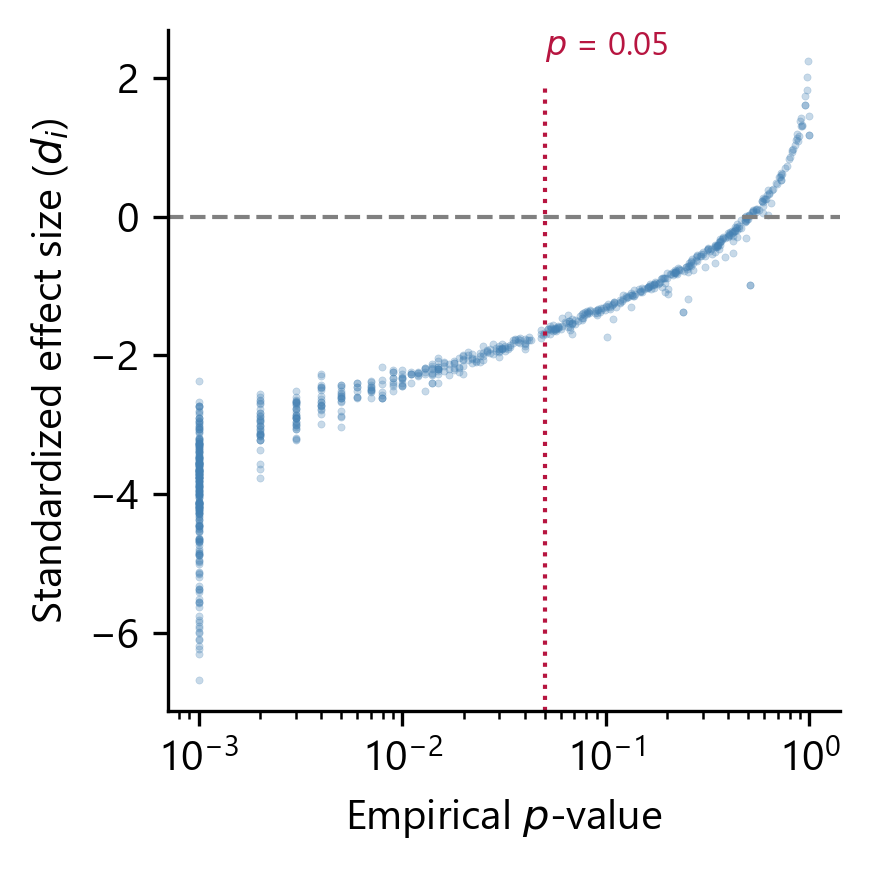

In [65]:
# Drop NaNs
df2plot = df_m_r.dropna(subset=['d_i', 'p_empirical'])

# Set up figure
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

# Base scatterplot
sns.scatterplot(
    data=df2plot,
    x='p_empirical',
    y='d_i',
    alpha=0.3,
    edgecolor=None,
    s=3,
    color='steelblue'
)

# Reference lines
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0.05, color='#b71540', linestyle=':', linewidth=1)
plt.text(
    0.05,                # x position
    plt.ylim()[1],       # top of the y-axis
    '$p$ = 0.05',          # label text
    color='#b71540',
    ha='left', va='top',
    fontsize=8,
    rotation=0,
    backgroundcolor='white'
)
# Labels and title
plt.xlabel("Empirical $p$-value")
plt.ylabel("Standardized effect size ($d_i$)")
# plt.title("Selectivity in Spatial Choices\n(p-value vs. Effect Size)")

# Clean up
sns.despine()
plt.xscale('log')
plt.tight_layout()
fig.savefig("figures/selectivity_effect_size.png", dpi=300, bbox_inches='tight')
plt.show()

In [66]:
len(df2plot[df2plot['p_empirical'] < 0.05]) / len(df2plot)

0.6266195524146054

In [67]:
cat_dict = {'entropy_mm': 'Leisure activity participation', 
            'activity_time_third': 'Leisure activity participation', 
            'total_travel_time': "Trip making", 'xs_total_hws': "Trip making", 
            'trip_chaining_presence': "Trip making", 
            'Gender': "Individual attributes", 
            #'main_mode_r': "Transport mode", 
            'Age': "Individual attributes", 
            'Education': "Individual attributes", 
            'Household_type': "Individual attributes", 
            'weight_ind': "Individual attributes", 
            'mode': "Transport mode", 
            'ak_cat': "Space-time accessibility", 
            'ak_log': "Space-time accessibility", 
            'pt_sub': "Transport mode", 
            'active_mode': "Individual attributes"}
cat_name_dict = {'entropy_mm': 'Third activity entropy', 
            'activity_time_third': 'Third activity time (min)', 
            'total_travel_time': "Total travel time (min)", 'xs_total_hws': "Trip chaining complexity", 
            'trip_chaining_presence': "Trip chaining presence", 
            'Gender': "Gender", 
            # 'main_mode_r': "Main transport mode", 
            'Age': "Age", 
            'Education': "Education", 
            'Household_type': "Household type", 
            'weight_ind': "Individual attributes", 
            'mode': "Main transport mode", 
            'ak_cat': "Space-time accessibility (> 0)", 
            'ak_log': "Space-time accessibility (log)", 
            'pt_sub': "Public transit subscription", 
            'active_mode': "Use of active mode"}
cat_list = ['trip_chaining_presence', 'Gender', 'Education', 'Household_type', 'mode', 'ak_cat', 'pt_sub', 'active_mode']
cat_level_dict = dict()
Education_dict = {
    'No diploma': 0,
    'Vocational': 1,
    'Lower secondary': 2,
    'Upper secondary': 3,
    '3–4-year higher education': 4,
    "5-year-and-above higher education": 5,
    "Missing": 9
}
household_order = {
    'Other': 0,
    'Other': 1,
    'Single parent': 2,
    'Living with parent(s)': 3,
    'Other': 4,
    'Other': 5,
    'In a couple w/ child(ren)': 6,
    'Other': 7
}
cat_level_dict['Education'] = {v: k for k, v in Education_dict.items()}
cat_level_dict['trip_chaining_presence'] = {0: 'w/o', 1: 'w/'}
cat_level_dict['Gender'] = {'Woman': 'Woman', 'Man': 'Man'}
cat_level_dict['Household_type'] = {v: k for k, v in household_order.items()}
cat_level_dict['mode'] = {'Car': 'Car', 'Public transit': 'Public transit'}
cat_level_dict['ak_cat'] = {'Zero': 'Zero', 'Non-zero': 'Non-zero'}
cat_level_dict['pt_sub'] = {True: 'Yes', False: 'No'}
cat_level_dict['active_mode'] = {1: 'Yes', 0: 'No'}

In [ ]:
# Drop missing values
df2plot = df_m_r.dropna(subset=['d_i', 'Household_type', 'p_empirical']).copy()

# Map categorical labels if needed
df2plot['active_mode'] = df2plot['active_mode'].map(cat_level_dict['active_mode'])
df2plot['Household_type'] = df2plot['Household_type'].map(cat_level_dict['Household_type'])

# Flag significance
df2plot['is_significant'] = df2plot['p_empirical'] < 0.05

# Set up horizontal plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)

# Boxplot (horizontal)
sns.boxplot(
    data=df2plot,
    y='Household_type',
    x='d_i',
    width=0.4,
    showcaps=True,
    showfliers=False,
    boxprops=dict(alpha=0.3, linewidth=1, facecolor='lightgray'),
    whiskerprops=dict(linewidth=1),
    medianprops=dict(color='black', linewidth=1.2)
)

# Jitter plot overlaid
sns.stripplot(
    data=df2plot,
    y='Household_type',
    x='d_i',
    hue='is_significant',
    palette={False: 'crimson', True: 'steelblue'},
    jitter=0.25,
    dodge=False,
    alpha=0.5,
    size=1,
    legend=False
)

# Labels
plt.ylabel("")
plt.xlabel("Effect size")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Set up horizontal plot
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

# Boxplot (horizontal)
sns.boxplot(
    data=df2plot,
    y='active_mode',
    x='d_i',
    width=0.2,
    showcaps=True,
    showfliers=False,
    boxprops=dict(alpha=0.3, linewidth=1, facecolor='lightgray'),
    whiskerprops=dict(linewidth=1),
    medianprops=dict(color='black', linewidth=1.2)
)

# Jitter plot overlaid
sns.stripplot(
    data=df2plot,
    y='active_mode',
    x='d_i',
    hue='is_significant',
    palette={False: 'crimson', True: 'steelblue'},
    jitter=0.25,
    dodge=False,
    alpha=0.5,
    size=1,
    legend=False
)

# Labels
plt.ylabel("Use of active mode")
plt.xlabel("Standardized effect size ($d_i$)")
sns.despine()
plt.tight_layout()
fig.savefig("figures/selectivity_active_mode.png", dpi=300, bbox_inches='tight')
plt.show()

In [83]:
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
df2plot = df_m_r.dropna(subset=['d_i', 'p_empirical', 'active_mode', 'weight_ind']).copy()

df_yes = df2plot[df2plot["active_mode"] == 1]
df_no  = df2plot[df2plot["active_mode"] == 0]

yes_stats = DescrStatsW(df_yes["d_i"], weights=df_yes["weight_ind"])
no_stats  = DescrStatsW(df_no["d_i"],  weights=df_no["weight_ind"])

cm = CompareMeans(yes_stats, no_stats)
test = cm.ttest_ind(usevar='unequal')

print("t-test statistic, p-value:", test)

t-test statistic, p-value: (np.float64(27.759584844526294), np.float64(1.4336287172878254e-169), np.float64(2087884.106826018))


In [ ]:
# ----- 1. Effect on effect size -----
model_entropy = smf.ols(
    formula="d_i ~ C(active_mode)", # poverty_rate + C(main_mode_r) + C(active_mode) + C(Household_type)
    data=df2plot
).fit(weights=df2plot["weight_ind"])

print("\n--- Effect size model (weighted) ---")
print(model_entropy.summary())


--- Effect size model (weighted) ---
                            OLS Regression Results                            
Dep. Variable:                    d_i   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6.255
Date:                tis, 02 dec 2025   Prob (F-statistic):             0.0126
Time:                        10:41:08   Log-Likelihood:                -1581.3
No. Observations:                 849   AIC:                             3167.
Df Residuals:                     847   BIC:                             3176.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------